In [1]:
import sys, transformers, accelerate, torch
print(sys.executable)
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("torch:", torch.__version__)


/home/ayato-kaku/miniconda3/envs/irm_iclr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/ayato-kaku/miniconda3/envs/irm_iclr/bin/python
transformers: 4.56.1
accelerate: 1.10.1
torch: 2.5.1+cu121


>> Using parquet: ./data/iclr/iclr25v2.parquet


Map: 100%|██████████| 3562/3562 [00:00<00:00, 10582.52 examples/s]
/tmp/ipykernel_86126/2584024537.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer)


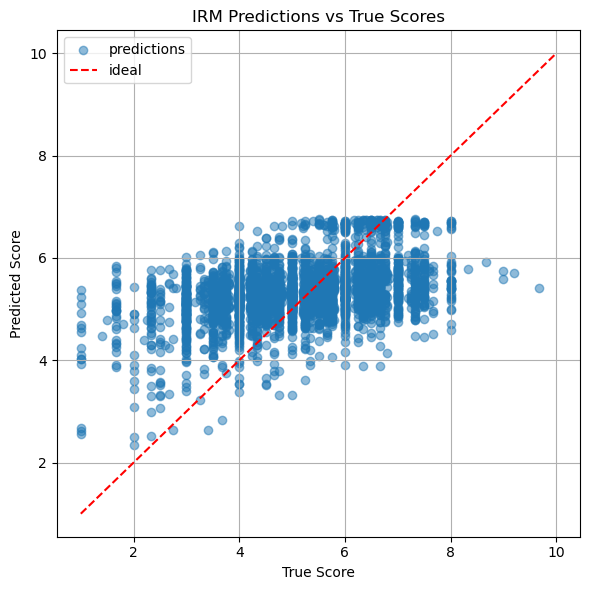

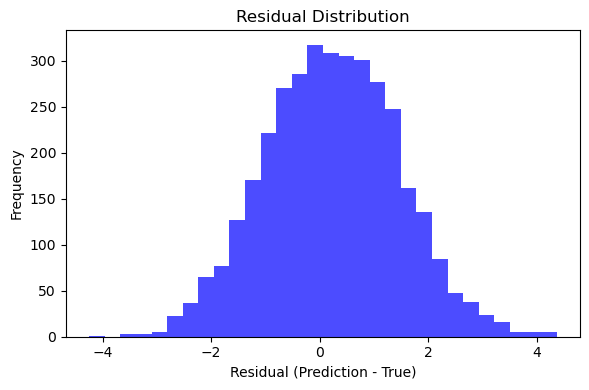

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
import torch

# 学習済みモデルのパス
MODEL_DIR = "./irm_iclr_model"

# モデルとトークナイザ読み込み
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.eval()

# 評価用データセット読み込み（trainで使ったdata_pathを指定）
from irm_iclr import DataConfig, make_dataset
dcfg = DataConfig(data_path="./data/iclr")
dsd, _ = make_dataset(dcfg)

valid = dsd["validation"]

# 予測
trainer = Trainer(model=model, tokenizer=tokenizer)
predictions = trainer.predict(valid)

y_true = predictions.label_ids
y_pred = predictions.predictions.reshape(-1)

# --- 1) 散布図（予測 vs 実ラベル） ---
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5, label="predictions")
plt.plot([1, 10], [1, 10], "r--", label="ideal")  # 理想線
plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title("IRM Predictions vs True Scores")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("irm_scatter.png", dpi=300)
plt.show()

# --- 2) 残差ヒストグラム ---
residuals = y_pred - y_true
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30, color="blue", alpha=0.7)
plt.xlabel("Residual (Prediction - True)")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.tight_layout()
plt.savefig("irm_residuals.png", dpi=300)
plt.show()
